In [6]:
''' what are we ging to try?
- One step forecasting
- Multi Step forecasting
- Multi output multi step forecasting'''

' what are we ging to try?\n- One step forecasting\n- Multi Step forecasting\n- Multi output multi step forecasting'

In [7]:
''' architectures we are going to try 
- Basic - keep outputs from only the final hidden unit h(T) and disregard all h(1) to h(T-1) before passing it to final output dense layer
- keep all h(t)s, and then do global max pooling before passing it to final output dense layer
- stack multiple LSTMs'''

' architectures we are going to try \n- Basic - keep outputs from only the final hidden unit h(T) and disregard all h(1) to h(T-1) before passing it to final output dense layer\n- keep all h(t)s, and then do global max pooling before passing it to final output dense layer\n- stack multiple LSTMs'

In [8]:
''' at any point of time we can try both LSTM and GRU'''

' at any point of time we can try both LSTM and GRU'

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D, LSTM, GRU
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint

np.random.seed(123)
tf.random.set_seed(123)

In [11]:
from sklearn.metrics import mean_absolute_percentage_error

In [12]:
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [13]:
df = pd.read_csv('airline_passengers.csv', index_col= 'Month', parse_dates = True)

In [14]:
df['LogPassengers'] = np.log(df['Passengers'])

In [15]:
Ntest=12
train = df[:-Ntest]
test = df[-Ntest:]

In [16]:
train_idx = df.index <= train.index[-1]
test_idx = ~train_idx

In [17]:
df['DiffLogPassengers'] = df['LogPassengers'].diff()

In [18]:
''' using differencing, but we could try without differencing as well'''

' using differencing, but we could try without differencing as well'

In [19]:
# ONE STEP FORECASTING

In [21]:
series = df['DiffLogPassengers'].dropna().to_numpy()

T = 10
X = []
Y = []

for t in range(len(series)-T):
    x = series[t:t+T]
    y = series[t+T]
    X.append(x)
    Y.append(y)

X = np.array(X).reshape(-1,T,1) # the data should be NxTxD as expected by RNNs even though D=1 for this univariate time series 
Y = np.array(Y)
N = len(X)
print("X.shape:", X.shape,"Y.shape:", Y.shape)

X.shape: (133, 10, 1) Y.shape: (133,)


In [22]:
''' look at the shape of X, its now having an extra dimension to make it N x T x D, previously , in all the codes, we were
using N x T dimentions.
imagine that it is NLP, x(t) is of D dimension, embedding vector size, and RNN is able to figure out the relationship between different measurements in
D different dimensions - same is the case  with time series and rnn as well - it is thus able to use the multivariate time series with no issues.
'''

' look at the shape of X, its now having an extra dimension to make it N x T x D, previously , in all the codes, we were\nusing N x T dimentions.\nimagine that it is NLP, x(t) is of D dimension, embedding vector size, and RNN is able to figure out the relationship between different measurements in\nD different dimensions - same is the case  with time series and rnn as well - it is thus able to use the multivariate time series with no issues.\n'

In [23]:
Xtrain, Ytrain = X[:-Ntest], Y[:-Ntest]
Xtest, Ytest = X[-Ntest:], Y[-Ntest:] 

In [24]:
Xtrain.shape

(121, 10, 1)

In [25]:
Xtest.shape

(12, 10, 1)

In [26]:
# RNN - BASIC APPROACH - JSUT USING THE FINAL HIDDEN STATE VECTOR H(T) AND DISREGARDING H(1) TO H(T-1)

i = Input(shape = (T,1))
x =  LSTM(24)(i)         # THIS IS MANY TO ONE AND ONLY OUTPUTTING H(T) SINCE WE ARE NOT USING return_sequence = True
x = Dense(1)(x)
model =  Model(i,x)

In [30]:
''' 24 above is the size of the hidden vector , each hidden vector having 24 elements'''
''' no activation function used in LSTM - uses tanh by default'''
''' the same lstm unit first processes x(1), updates it weights , produces h(1), then moves to x(2) and consumes h(1) as well , updates it weights , 
moves on going forward till x(T).'''
''' after processing final x(T), it will output h(T) and throw away previous calculated h(1) to h(T-1)'''

' after processing final x(T), it will output h(T) and throw away previous calculated h(1) to h(T-1)'

In [27]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 24)             │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,521 (9.85 KB)

 Trainable params: 2,521 (9.85 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
''' None in the shapes above means "N" - number of samples'''

' None in the shapes above means "N" - number of samples'

In [32]:
model.compile(
    loss = 'mse',
    optimizer = 'adam',
)

In [33]:
r = model.fit(
    Xtrain,
    Ytrain,
    epochs = 100,
    validation_data = (Xtest, Ytest)
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - loss: 0.0119 - val_loss: 0.0116
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0113 - val_loss: 0.0114
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0111 - val_loss: 0.0112
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0109 - val_loss: 0.0109
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0107 - val_loss: 0.0106
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0104 - val_loss: 0.0102
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0101 - val_loss: 0.0098
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0098 - val_loss: 0.0093
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0095 - val_loss: 0.0089
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0091 - val_loss: 0.0084
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0086 - val_loss: 0.0078
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0081 - val_l

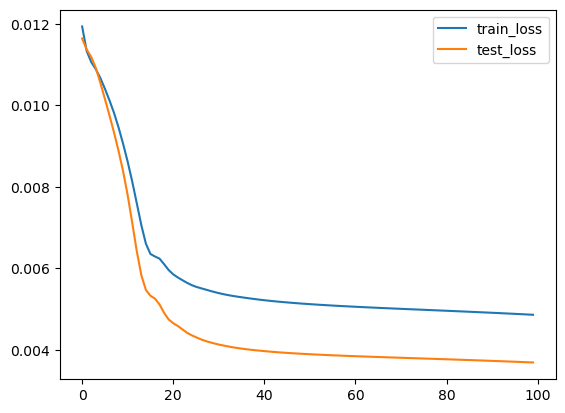

In [34]:
plt.plot(r.history['loss'], label = 'train_loss' )
plt.plot(r.history['val_loss'], label = 'test_loss' )
plt.legend();

In [35]:
train_idx[:T+1] = False # these are non predictable

In [36]:
Ptrain = model.predict(Xtrain).flatten()
Ptest = model.predict(Xtest).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [39]:
df.loc[train_idx, 'Diff Train Prediction'] = Ptrain
df.loc[test_idx, 'Diff Test Prediction'] = Ptest

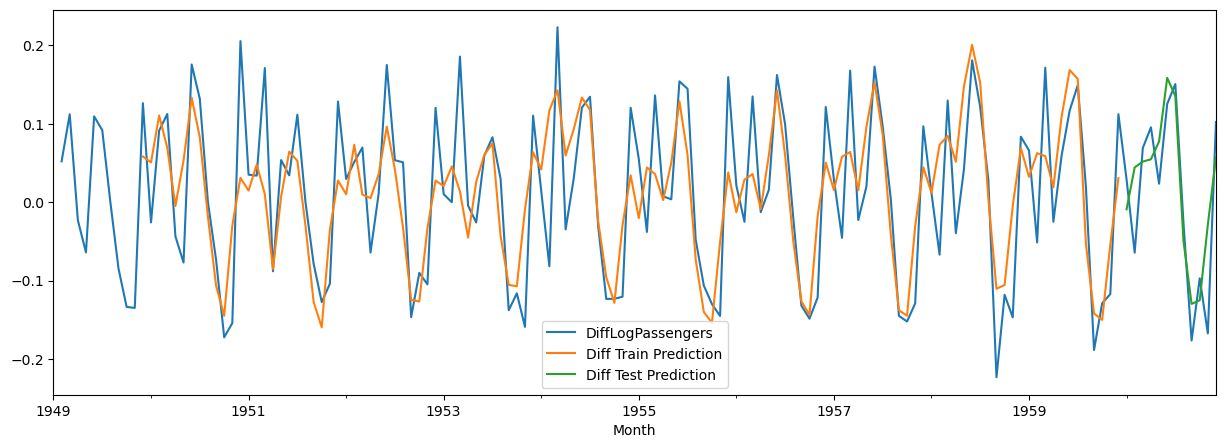

In [40]:
cols = ['DiffLogPassengers','Diff Train Prediction','Diff Test Prediction']
df[cols].plot(figsize =(15,5));

In [41]:
# computing un differenced predictions
df['ShiftLogPassengers'] = df['LogPassengers'].shift(1)
prev = df['ShiftLogPassengers']

In [42]:
last_train = train.iloc[-1]['LogPassengers']

In [43]:
# 1step forecast
df.loc[train_idx, '1step_train'] = prev[train_idx] + Ptrain
df.loc[test_idx, '1step_test'] = prev[test_idx] + Ptest

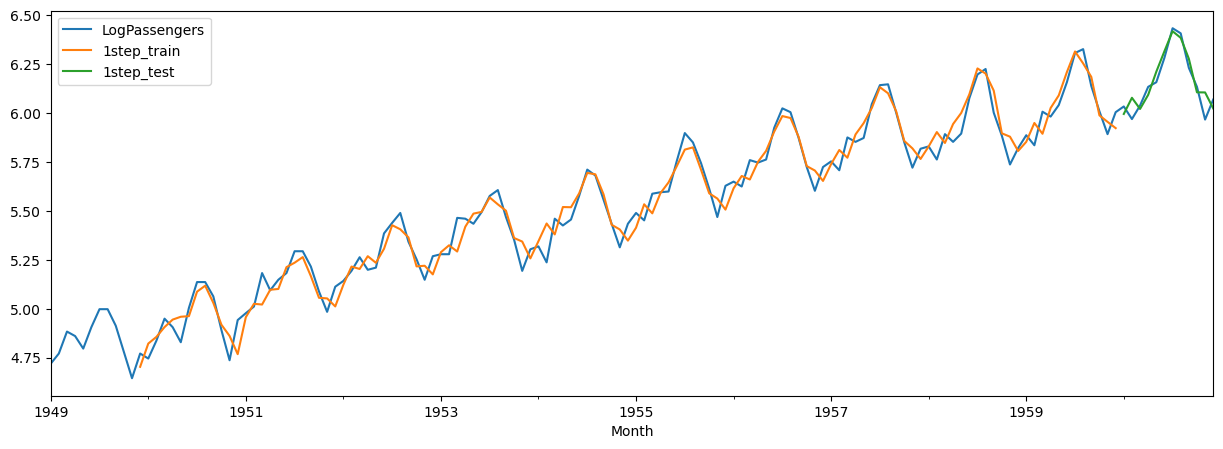

In [44]:
# plot 1 step forecast
df[['LogPassengers','1step_train','1step_test']].plot(figsize =(15,5));

In [45]:
'''looks good but explained earlier that this is not the correct method since data leakage happening in test set.
labels in the 1st row appear as features in the 2nd row, hence model might be able to cheat
'''

'looks good but explained earlier that this is not the correct method since data leakage happening in test set.\nlabels in the 1st row appear as features in the 2nd row, hence model might be able to cheat\n'

In [46]:
print(Xtest.shape)
print(Xtest[0].shape)

(12, 10, 1)
(10, 1)


In [47]:
# testing some code
xyz = Xtest[0]
print (xyz)
xyz = np.roll(xyz, -1)
print(xyz)
print(xyz[-1])

[[ 0.17154242]
 [-0.02493895]
 [ 0.0588405 ]
 [ 0.11672427]
 [ 0.1492963 ]
 [ 0.01987419]
 [-0.18842242]
 [-0.12891387]
 [-0.11716897]
 [ 0.11224286]]
[[-0.02493895]
 [ 0.0588405 ]
 [ 0.11672427]
 [ 0.1492963 ]
 [ 0.01987419]
 [-0.18842242]
 [-0.12891387]
 [-0.11716897]
 [ 0.11224286]
 [ 0.17154242]]
[0.17154242]


In [48]:
#multistep forecast
multistep_predictions = []
last_x = Xtest[0]

while len(multistep_predictions) < Ntest:
    p = model.predict(last_x.reshape(1,-1, 1))[0] # notice that the reshape is now changed to make the data (NxTxD), previously we used to reshape (1, -1)
    multistep_predictions.append(p)

    last_x = np.roll(last_x, -1)
    last_x[-1] = p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


In [49]:
df.loc[test_idx, 'multistep'] = last_train + np.cumsum(multistep_predictions)

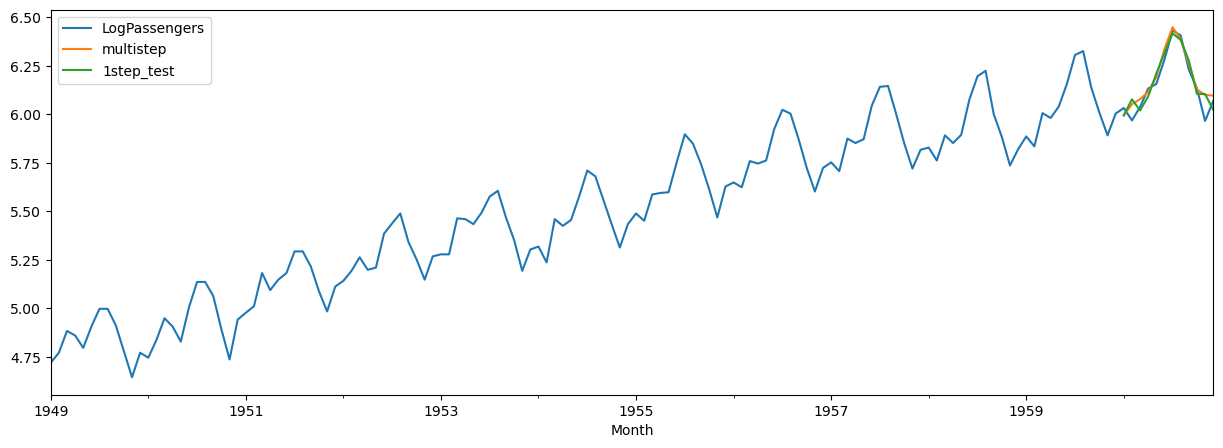

In [50]:
df[['LogPassengers','multistep','1step_test']].plot(figsize =(15,5));

In [51]:
'''1 step slightly better'''

'1 step slightly better'

In [52]:
# multi output supervised 
Tx = T
Ty = Ntest
X = []
Y = []

for t in range(len(series) - Tx -Ty + 1):
    x = series[t:t+Tx]
    X.append(x)
    y = series[t+Tx:t+Tx+Ty] 
    Y.append(y)

X = np.array(X).reshape(-1, Tx, 1) # notice that we have reshaped the data here to be N X T X D
Y = np.array(Y).reshape(-1, Ty)
N = len(X)
print("X.shape",X.shape, "Y.shape", Y.shape)

X.shape (122, 10, 1) Y.shape (122, 12)


In [53]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [54]:
Xtrain_m.shape, Ytrain_m.shape

((121, 10, 1), (121, 12))

In [55]:
Xtest_m.shape, Ytest_m.shape

((1, 10, 1), (1, 12))

In [56]:
#RNN - diff architecture used here - we could have used the exact same architecture as before with only the final output layer being of the
# dimension Ty - here we are using all the hidden states , h(1) to h(T)

i = Input(shape = (Tx,1))
x = LSTM(24,return_sequences = True)(i)   #returns all the hidden states h(1) to h(T), returns T x M 
x = GlobalMaxPooling1D()(x) 
x = Dense(Ty)(x)
model =  Model(i,x)

In [61]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 24)         │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 24)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,390 (32.78 KB)

 Trainable params: 2,796 (10.92 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,594 (21.86 KB)

In [62]:
''' notice that global max pooling 1d is reducing the dimension and taking max along T and thus removes T dimensions altogether'''

' notice that global max pooling 1d is reducing the dimension and taking max along T and thus removes T dimensions altogether'

In [57]:
model.compile(loss='mse', optimizer='adam')

In [58]:
check_point = ModelCheckpoint('best_model.h5', monitor = 'val_loss', save_best_only = True)

In [59]:
r = model.fit(
    Xtrain_m,
    Ytrain_m,
    epochs = 300,
    validation_data = (Xtest_m, Ytest_m),
    callbacks = [check_point,]
)

Epoch 1/300
1/4 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - loss: 0.0117

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 652ms/step - loss: 0.0115 - val_loss: 0.0114
Epoch 2/300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0114

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0113 - val_loss: 0.0113
Epoch 3/300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0113

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0112 - val_loss: 0.0113
Epoch 4/300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.0113

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0112 - val_loss: 0.0112
Epoch 5/300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0112

...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0032 - val_loss: 0.0025
Epoch 180/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0032 - val_loss: 0.0025
Epoch 181/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0032 - val_loss: 0.0025
Epoch 182/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0032 - val_loss: 0.0025
Epoch 183/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0032 - val_loss: 0.0025
Epoch 184/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0032 - val_loss: 0.0025
Epoch 185/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0032 - val_loss: 0.0025
Epoch 186/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0032 - val_loss: 0.0025
Epoch 187/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0031 - val_loss: 0.0025
Epoch 188/300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0029

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0031 - val_loss: 0.0025
Epoch 189/300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.0029

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0031 - val_loss: 0.0025
Epoch 190/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0031 - val_loss: 0.0025
Epoch 191/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0031 - val_loss: 0.0025
Epoch 192/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0031 - val_loss: 0.0025
Epoch 193/300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0029

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0031 - val_loss: 0.0025
Epoch 194/300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0029

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0031 - val_loss: 0.0024
Epoch 195/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0031 - val_loss: 0.0025
Epoch 196/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0031 - val_loss: 0.0025
Epoch 197/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0031 - val_loss: 0.0025
Epoch 198/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0031 - val_loss: 0.0025
Epoch 199/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0030 - val_loss: 0.0024
Epoch 200/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0030 - val_loss: 0.0024
Epoch 201/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0030 - val_loss: 0.0025
Epoch 202/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0030 - val_loss: 0.0024
Epoch 203/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0030 - val_loss: 0.0024
Epoch 204/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0030 - val_loss: 0.0025
Epoch 205/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0030 -

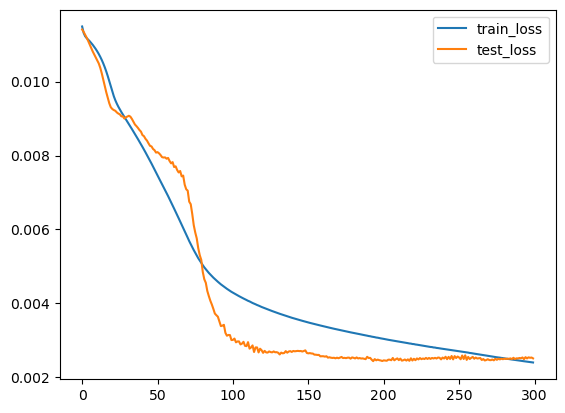

In [60]:
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'test_loss')
plt.legend();

In [66]:
Ptrain = model.predict(Xtrain_m)
Ptest = model.predict(Xtest_m)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [67]:
Ptrain.shape, Ptest.shape

((121, 12), (1, 12))

In [68]:
Ptrain = Ptrain[:,0] # keeping the closest predictions closer to current time since we believe it to be more accurate

In [69]:
# this is how the original Ptrain was - we just took the 1st column
# y1, y2, y3
# y2, y3, y4
# y3, y4, y5

In [70]:
print(Ptest)
print(Ptest[0])  # just grabbing the 0th row - no more rows since test has only 1 row of data
Ptest = Ptest[0]

[[ 0.04605185 -0.07420638  0.15981618 -0.00528977 -0.02016431  0.18082346
   0.13091226 -0.0085819  -0.1410552  -0.1365535  -0.11873481  0.0810229 ]]
[ 0.04605185 -0.07420638  0.15981618 -0.00528977 -0.02016431  0.18082346
  0.13091226 -0.0085819  -0.1410552  -0.1365535  -0.11873481  0.0810229 ]


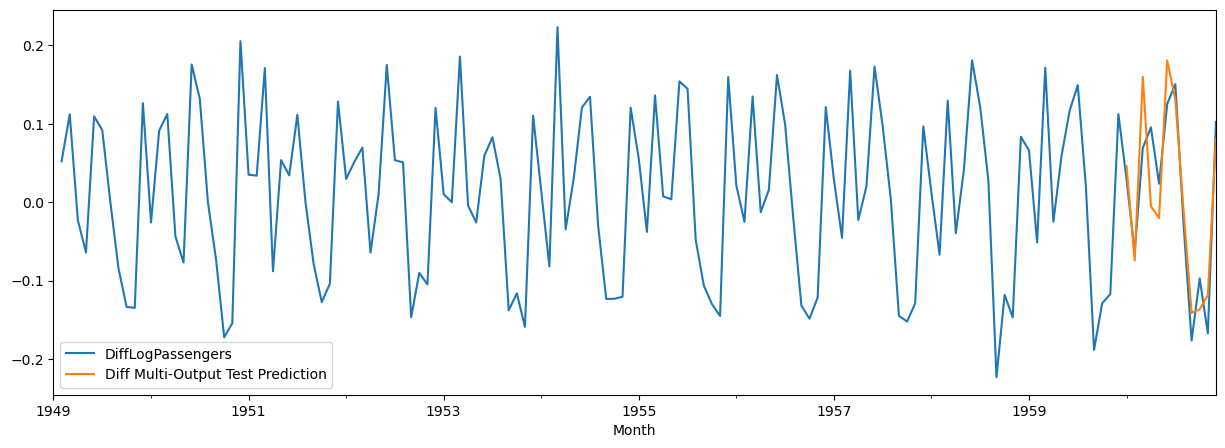

In [71]:
df.loc[test_idx, 'Diff Multi-Output Test Prediction'] = Ptest
cols = ['DiffLogPassengers','Diff Multi-Output Test Prediction']
df[cols].plot(figsize=(15,5));

In [72]:
''' predictions look fine'''

' predictions look fine'

In [73]:
df.loc[test_idx, 'multioutput'] = last_train + np.cumsum(Ptest)

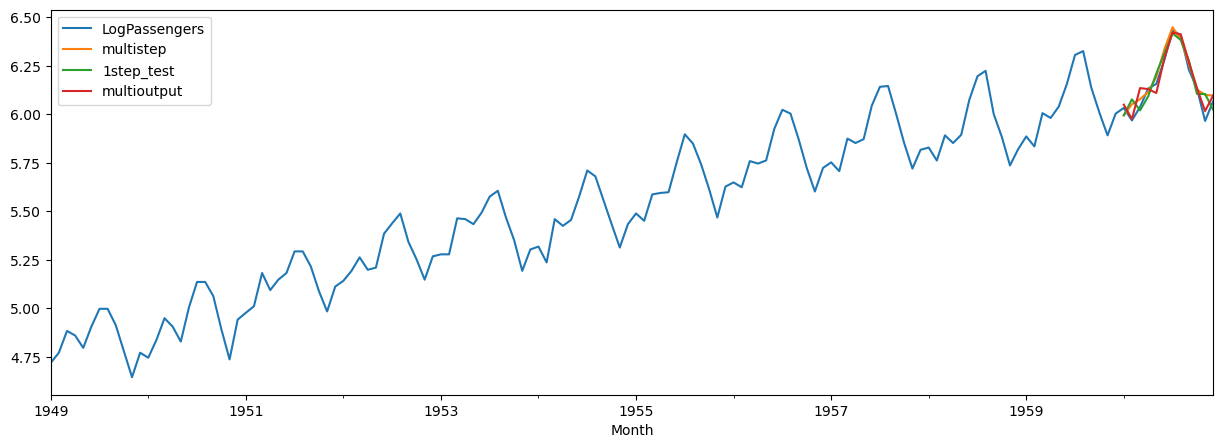

In [74]:
df[['LogPassengers','multistep','1step_test','multioutput']].plot(figsize =(15,5));

In [75]:
# RNN - multiple stacked LSTM Layers

i = Input(shape = (Tx,1))
x = LSTM(16,return_sequences = True)(i)   #returns all the hidden states h(1) to h(T), returns T x M 
x = LSTM(16,return_sequences = True)(x)   #returns all the hidden states h(1) to h(T), returns T x M , used 16 and not 24 since more layers now
x = GlobalMaxPooling1D()(x) 
x = Dense(Ty)(x)
model =  Model(i,x)


In [76]:
check_point = ModelCheckpoint('best_model.h5', monitor = 'val_loss', save_best_only = True)

In [77]:
model.compile(loss='mse', optimizer='adam')

In [78]:
r = model.fit(
    Xtrain_m,
    Ytrain_m,
    epochs = 300,
    validation_data = (Xtest_m, Ytest_m),
    callbacks = [check_point,]
)

Epoch 1/300
1/4 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - loss: 0.0116

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 280ms/step - loss: 0.0115 - val_loss: 0.0114
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0114 - val_loss: 0.0115
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0113 - val_loss: 0.0116
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0113 - val_loss: 0.0116
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0113 - val_loss: 0.0115
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0112 - val_loss: 0.0115
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0112 - val_loss: 0.0115
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0112 - val_loss: 0.0115
Epoch 9/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0111 - val_loss: 0.0115
Epoch 10/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0111 - val_loss: 0.0115
Epoch 11/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0110 - val_loss: 0.0115
Epoch 12/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0110 - val_loss: 0.0114


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0096 - val_loss: 0.0112
Epoch 27/300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0093

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0095 - val_loss: 0.0109
Epoch 28/300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0092

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0095 - val_loss: 0.0106
Epoch 29/300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0092

...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0031 - val_loss: 0.0031
Epoch 296/300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 0.0033

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0031 - val_loss: 0.0031
Epoch 297/300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0033

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0031 - val_loss: 0.0031
Epoch 298/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0031 - val_loss: 0.0031
Epoch 299/300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0033

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0031 - val_loss: 0.0031
Epoch 300/300
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0033

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0031 - val_loss: 0.0031


In [79]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 16)         │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 10, 16)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 16)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,406 (40.65 KB)

 Trainable params: 3,468 (13.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,938 (27.11 KB)

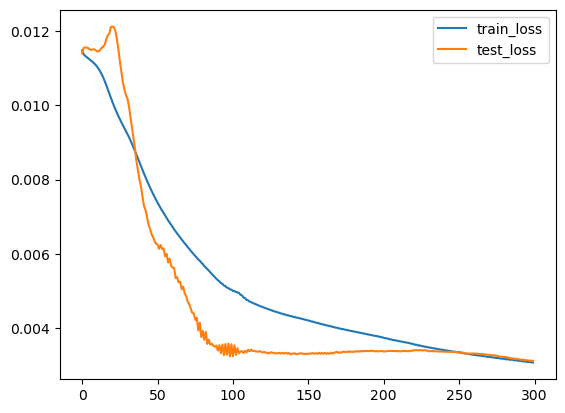

In [80]:
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'test_loss')
plt.legend();

In [82]:
Ptrain = model.predict(Xtrain_m)
Ptest = model.predict(Xtest_m)

Ptrain = Ptrain[:,0] # keeping the closest predictions closer to current time since we believe it to be more accurate

Ptest = Ptest[0]

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


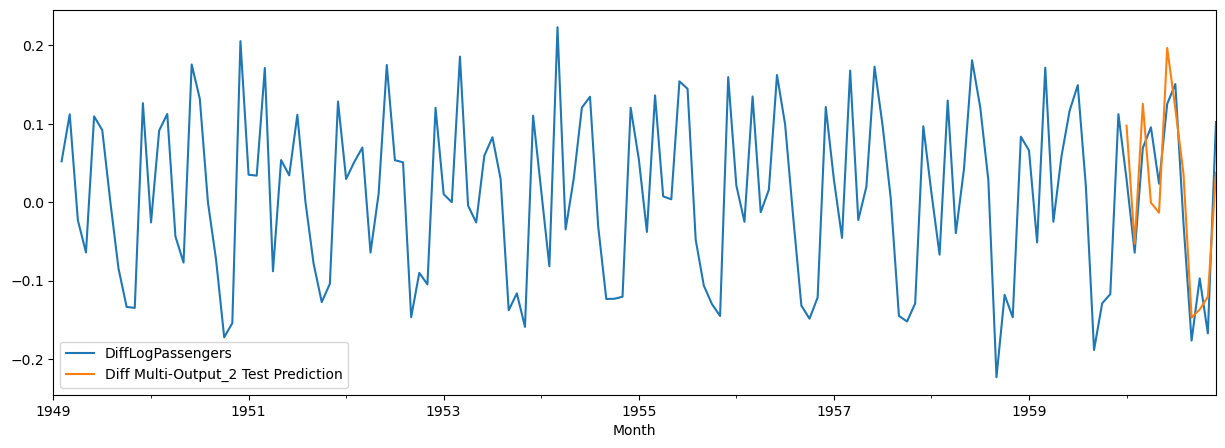

In [83]:
df.loc[test_idx, 'Diff Multi-Output_2 Test Prediction'] = Ptest
cols = ['DiffLogPassengers','Diff Multi-Output_2 Test Prediction']
df[cols].plot(figsize=(15,5));



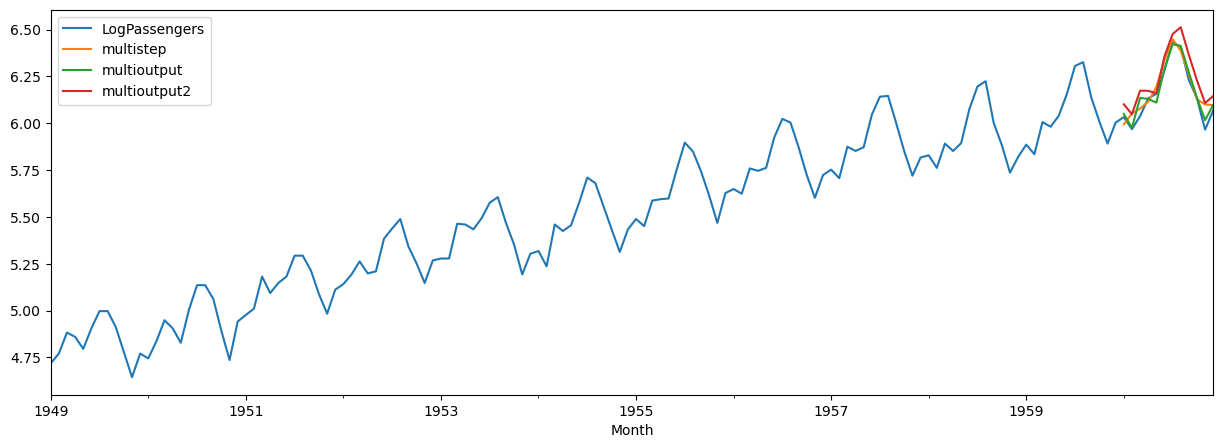

In [85]:
df.loc[test_idx, 'multioutput2'] = last_train + np.cumsum(Ptest)


df[['LogPassengers','multistep','multioutput','multioutput2']].plot(figsize =(15,5));

In [86]:
''' stacked layers overestimating'''

' stacked layers overestimating'

In [87]:
test_log_pass = df.iloc[-Ntest:]['LogPassengers']
mape1 =  mean_absolute_percentage_error(test_log_pass, df.loc[test_idx, 'multistep'])
mape2 =  mean_absolute_percentage_error(test_log_pass, df.loc[test_idx, 'multioutput'])
mape3 =  mean_absolute_percentage_error(test_log_pass, df.loc[test_idx, 'multioutput2'])
print("multistep MAPE:", mape1)
print("multioutput MAPE:", mape2)
print("multioutput (stacked lstms) MAPE:", mape3)

multistep MAPE: 0.006908790104428753
multioutput MAPE: 0.004400185387599229
multioutput (stacked lstms) MAPE: 0.013600128911901226


In [88]:
''' single lstm doing much better than stacked lstm. so adding multiple layers doesnt guarantee improved performance'''

' single lstm doing much better than stacked lstm. so adding multiple layers doesnt guarantee improved performance'

In [89]:
''' we can also see if logging, differencing is necessary,optimizing for lags etc?
Also, walkforward validation is necessary to see which hyperaparameters are the best and produce consistently better result'''

' we can also see if logging, differencing is necessary,optimizing for lags etc?\nAlso, walkforward validation is necessary to see which hyperaparameters are the best and produce consistently better result'